# Test of InstaSHAP

In [1]:
import torch
import numpy as np
import copy
import os
from torch.utils.data import TensorDataset, DataLoader

from sian.models import TrainingArgs

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.instashap import surrogate, InstaSHAP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/opt/miniconda3/envs/ml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Step1: Prepare the data
use the bike_sharing data as in the paper https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [2]:
dataset_str = "bike_sharing" 
data_base_path = "../data/"
dataset_path = data_base_path + dataset_str + "/"

In [3]:
def preprocess_bike_sharing_dataset(load_dataset_path):
    import numpy as np
    
    csv_path = os.path.join(load_dataset_path, 'hour.csv')
    print(f"Processing file: {csv_path}")
    
    file = open(csv_path, 'r')
    lines = file.readlines()
    file.close()
    
    header = lines[0]
    data_lines = lines[1:]
    N = len(data_lines)
    bike_share_data = np.zeros((N, 17))

    for i, line in enumerate(data_lines):
        values = line.strip().split(',')
        day = int(values[1][8:10])
        values[1] = day

        bike_share_data[i] = [float(val) for val in values]
        
    # 1. Drop the first column (instant ID) -> 16 columns left
    bike_share_data = bike_share_data[:, 1:] 
    
    # 2. Log transform specific columns (casual, registered, cnt)
    bike_share_data[:, 13:16] = np.log(1 + bike_share_data[:, 13:16])
    
    # 3. extract X (Features) and Y (Target)
    
    X = bike_share_data[:, :13]  # Features: dteday(modified) to windspeed
    Y = bike_share_data[:, 15]   # Target: cnt (total count)
    
    XY_stuff = (X, Y, None, False, None)

    # Labels 
    readable_labels = {
        0 : "day", 1 : "season", 2 : "year", 3 : "month", 4 : "hour",
        5 : "holiday", 6 : "day of week", 7 : "workday",
        8 : "weather", 9 : "temperature", 10 : "feels_like_temp",
        11 : "humidity", 12 : "wind speed",
    }
    
    
    full_readable_labels = {
        'task_type' : "regression",
    }
    
    label_stuff = (readable_labels, full_readable_labels)
    print('--- processed and NOT saved ---')

    return XY_stuff, label_stuff

In [4]:
class CustomBikeDataset:
    def __init__(self, data_path, seed=None):
        XY_stuff, label_stuff = preprocess_bike_sharing_dataset(data_path)
        
        raw_X, raw_Y = XY_stuff[0], XY_stuff[1]

        if len(raw_Y.shape) == 1:
            raw_Y = raw_Y[:, None]
        
        total_len = raw_X.shape[0]
        test_split_idx = int(total_len * 0.8)

        self.trnvalX = raw_X[:test_split_idx]
        self.trnvalY = raw_Y[:test_split_idx]
        self.tstX = raw_X[test_split_idx:]
        self.tstY = raw_Y[test_split_idx:]

        self.trnX, self.valX, self.trnY, self.valY = None, None, None, None

        self.readable_labels = label_stuff[0]
        
        self.label_stuff_dict = {
            "readable_labels": self.readable_labels,
            "full_readable_labels": {
                "task_type": "regression",
                "D0": self.trnvalX.shape[1]
            }
        }

    def shuffle_and_split_trnval(self, trnval_shuffle_seed=None, trnval_split_percentage=0.7):
        if trnval_shuffle_seed is None:
            np.random.seed(None)
            self.trnval_shuffle_seed = np.random.randint(0, 10000)
        else:
            self.trnval_shuffle_seed = trnval_shuffle_seed
            
        np.random.seed(self.trnval_shuffle_seed)
        print('trnval_shuffle_seed:', self.trnval_shuffle_seed)

        M_NUM = self.trnvalX.shape[0]
        rand_indices = np.random.permutation(M_NUM)
        M_TRN_NUM = int(M_NUM * trnval_split_percentage)
        
        self.trnX = self.trnvalX[rand_indices[:M_TRN_NUM]]
        self.valX = self.trnvalX[rand_indices[M_TRN_NUM:]]
        self.trnY = self.trnvalY[rand_indices[:M_TRN_NUM]]
        self.valY = self.trnvalY[rand_indices[M_TRN_NUM:]]

    def pull_data(self):
        return (self.trnvalX, self.trnvalY, self.tstX, self.tstY)

    def pull_trnval_data(self):
        if self.trnX is None:
            raise Exception("Please call shuffle_and_split_trnval() first!")
        return (self.trnX, self.trnY, self.valX, self.valY)

    def get_D(self):
        return self.trnvalX.shape[1]
        
    def get_C(self):
        return self.trnvalY.shape[1]

    def get_dataset_id(self):
        return "bike_sharing_custom"
        
    def get_readable_labels(self):
        return self.label_stuff_dict["readable_labels"]
        
    def get_full_readable_labels(self):
        return self.label_stuff_dict["full_readable_labels"]

    def get_task_type(self):
        return self.get_full_readable_labels()["task_type"]

    def get_grouped_feature_dict(self):
        D = self.get_D()
        
        grouped_features_dict = {}
        grouped_features_dict["D"] = D
        grouped_features_dict["D0"] = D
        
        for i in range(D):
            grouped_features_dict[i] = [i]
            
        return grouped_features_dict

In [5]:
print("Initializing Custom Dataset...")
dataset_obj = CustomBikeDataset(dataset_path, seed=37)
dataset_obj.shuffle_and_split_trnval()
print(f"Dataset ready. X shape: {dataset_obj.trnX.shape}, Y shape: {dataset_obj.trnY.shape}")

Initializing Custom Dataset...
Processing file: ../data/bike_sharing/hour.csv
--- processed and NOT saved ---
trnval_shuffle_seed: 8217
Dataset ready. X shape: (9732, 13), Y shape: (9732, 1)


## Step2: Train Mask MLP
find the interactions

trnval_shuffle_seed: 0
trnX trnY (9732, 13) (9732, 1)
Epoch 0
MSE for train and val: 2.156072224686359, 2.1292583450164235
--- 0.241 seconds in epoch ---
Epoch 1
MSE for train and val: 0.9724324326509799, 0.9396296693863574
--- 0.190 seconds in epoch ---
Epoch 2
MSE for train and val: 0.9340055071017072, 0.898854253743054
--- 0.188 seconds in epoch ---
Epoch 3
MSE for train and val: 0.9614313738742073, 0.9195023751041167
--- 0.185 seconds in epoch ---
Epoch 4
MSE for train and val: 0.8454141460260218, 0.8141716064692202
--- 0.188 seconds in epoch ---
Epoch 5
MSE for train and val: 0.622552334105735, 0.6189523209326102
--- 0.187 seconds in epoch ---
Epoch 6
MSE for train and val: 0.6649245714388488, 0.64368281203293
--- 0.191 seconds in epoch ---
Epoch 7
MSE for train and val: 0.883615346570303, 0.8556568858637759
--- 0.183 seconds in epoch ---
Epoch 8
MSE for train and val: 0.4056952811632652, 0.4012833042151768
--- 0.187 seconds in epoch ---
Epoch 9
MSE for train and val: 0.7024674055

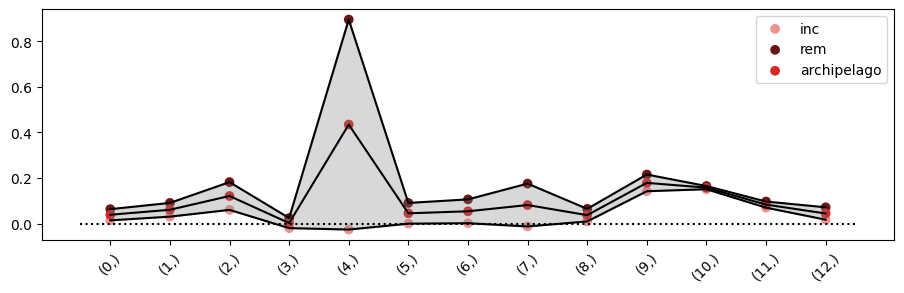

new_selections [(4,)]
selections [(4,)]
new_cands []
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (9,), (10,), (11,), (12,)]
0.10874605178833008 seconds
nr 1
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


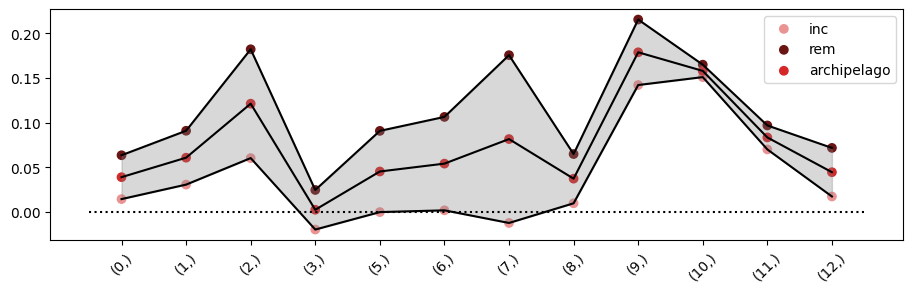

new_selections [(9,)]
selections [(4,), (9,)]
new_cands [(4, 9)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (10,), (11,), (12,), (4, 9)]
0.19963288307189941 seconds
nr 2
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


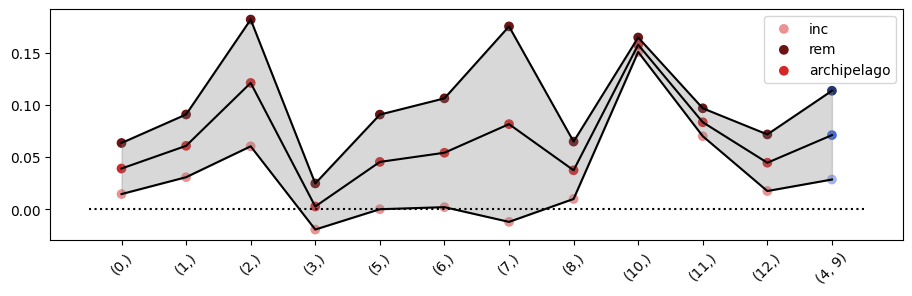

new_selections [(10,)]
selections [(4,), (9,), (10,)]
new_cands [(4, 9), (4, 10), (9, 10)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (11,), (12,), (4, 9), (4, 10), (9, 10)]
0.37620091438293457 seconds
nr 3
archipelago_tensor (13, 2, 4171)
semitruth torch.Size([4171, 1])


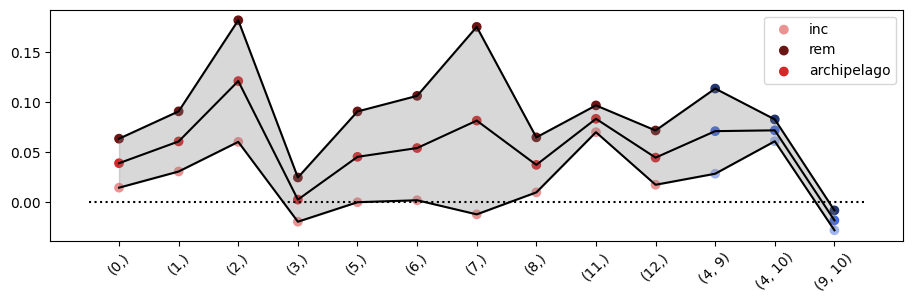

new_selections [(2,)]
selections [(4,), (9,), (10,), (2,)]
new_cands [(4, 9), (4, 10), (2, 4), (9, 10), (2, 9), (2, 10)]
candidates [(0,), (1,), (3,), (5,), (6,), (7,), (8,), (11,), (12,), (4, 9), (4, 10), (9, 10), (2, 4), (2, 9), (2, 10)]
0.4855349063873291 seconds
nr 4
archipelago_tensor (15, 2, 4171)
semitruth torch.Size([4171, 1])


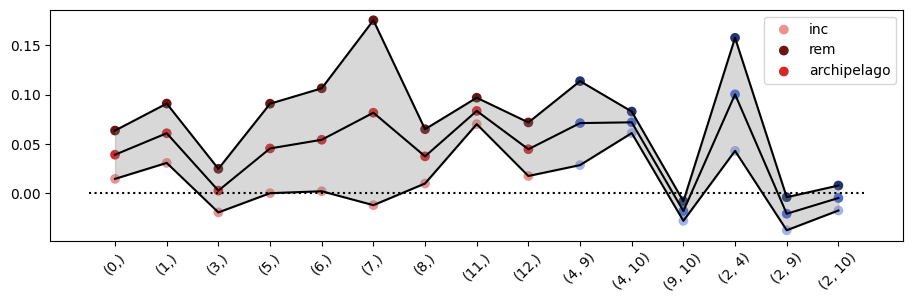

new_selections [(2, 4)]
selections [(4,), (9,), (10,), (2,), (2, 4)]
new_cands [(4, 9), (4, 10), (2, 4), (9, 10), (2, 9), (2, 10)]
candidates [(0,), (1,), (3,), (5,), (6,), (7,), (8,), (11,), (12,), (4, 9), (4, 10), (9, 10), (2, 9), (2, 10)]
0.6038987636566162 seconds
nr 5
archipelago_tensor (14, 2, 4171)
semitruth torch.Size([4171, 1])


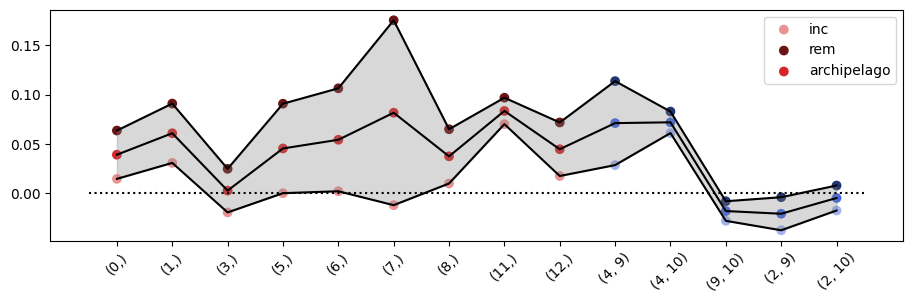

new_selections [(11,)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (9, 10), (2, 9), (9, 11), (2, 10), (10, 11), (2, 11)]
candidates [(0,), (1,), (3,), (5,), (6,), (7,), (8,), (12,), (4, 9), (4, 10), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11)]
0.7121169567108154 seconds
nr 6
archipelago_tensor (17, 2, 4171)
semitruth torch.Size([4171, 1])


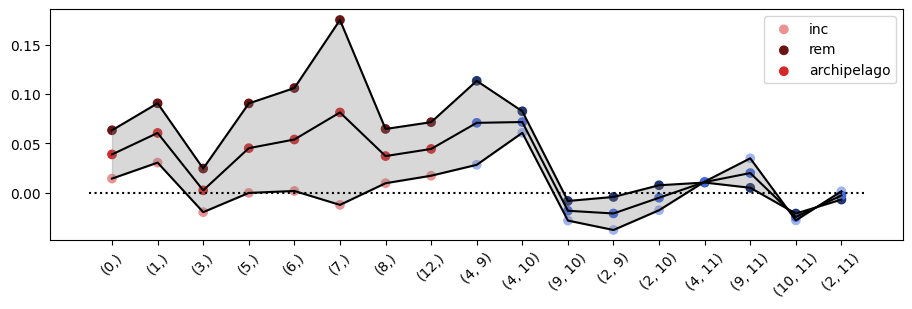

new_selections [(7,)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (9, 10), (2, 9), (9, 11), (7, 9), (2, 10), (10, 11), (7, 10), (2, 11), (2, 7), (7, 11)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (4, 9), (4, 10), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (4, 7), (7, 9), (7, 10), (2, 7), (7, 11)]
0.8605308532714844 seconds
nr 7
archipelago_tensor (21, 2, 4171)
semitruth torch.Size([4171, 1])


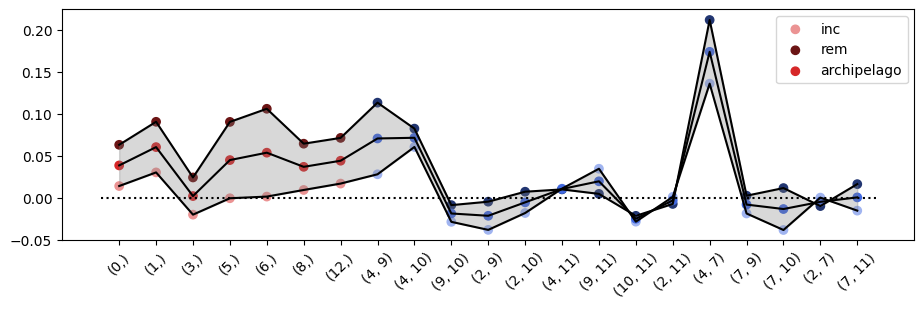

new_selections [(4, 7)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (9, 10), (2, 9), (9, 11), (7, 9), (2, 10), (10, 11), (7, 10), (2, 11), (2, 7), (7, 11), (2, 4, 7)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (4, 9), (4, 10), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7)]
1.0204968452453613 seconds
nr 8
archipelago_tensor (21, 2, 4171)
semitruth torch.Size([4171, 1])


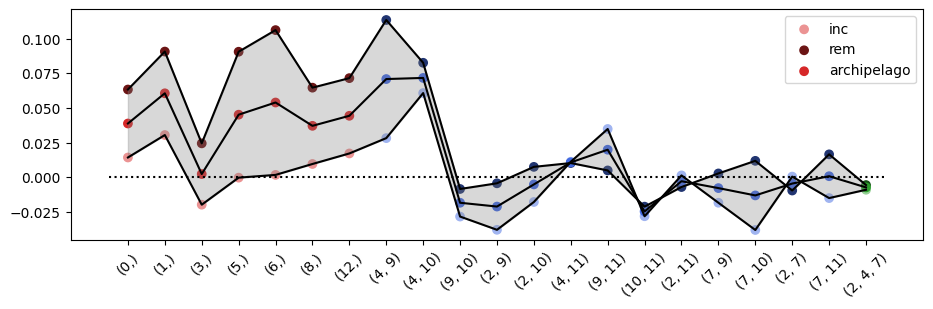

new_selections [(4, 10)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (9, 10), (2, 9), (9, 11), (7, 9), (2, 10), (10, 11), (7, 10), (2, 11), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (4, 9), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10)]
1.1790950298309326 seconds
nr 9
archipelago_tensor (22, 2, 4171)
semitruth torch.Size([4171, 1])


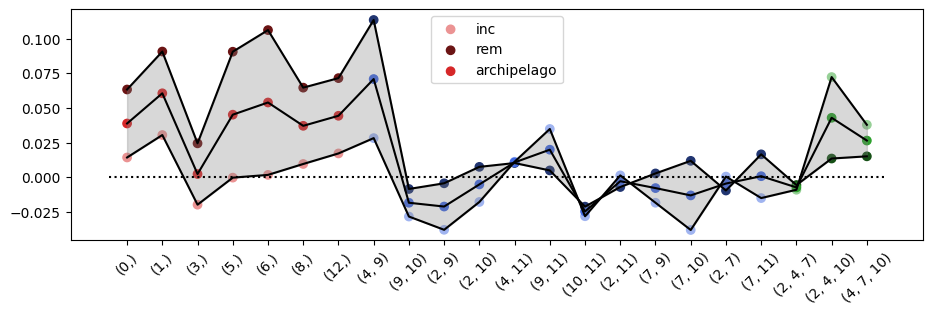

new_selections [(4, 9)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (9, 10), (2, 9), (9, 11), (7, 9), (2, 10), (10, 11), (7, 10), (2, 11), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (2, 4, 9), (4, 7, 10), (4, 7, 9), (4, 9, 10)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10)]
1.3508741855621338 seconds
nr 10
archipelago_tensor (24, 2, 4171)
semitruth torch.Size([4171, 1])


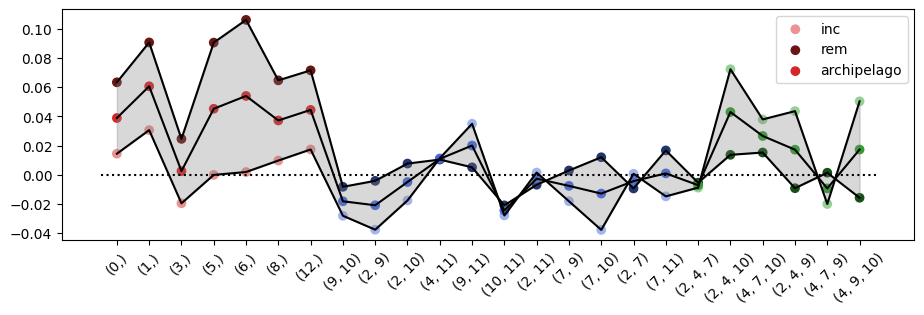

new_selections [(1,)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (1, 4), (9, 10), (2, 9), (9, 11), (7, 9), (1, 9), (2, 10), (10, 11), (7, 10), (1, 10), (2, 11), (2, 7), (1, 2), (7, 11), (1, 11), (1, 7), (2, 4, 7), (2, 4, 10), (2, 4, 9), (4, 7, 10), (4, 7, 9), (4, 9, 10)]
candidates [(0,), (3,), (5,), (6,), (8,), (12,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10), (1, 4), (1, 9), (1, 10), (1, 2), (1, 11), (1, 7)]
1.5565550327301025 seconds
nr 11
archipelago_tensor (29, 2, 4171)
semitruth torch.Size([4171, 1])


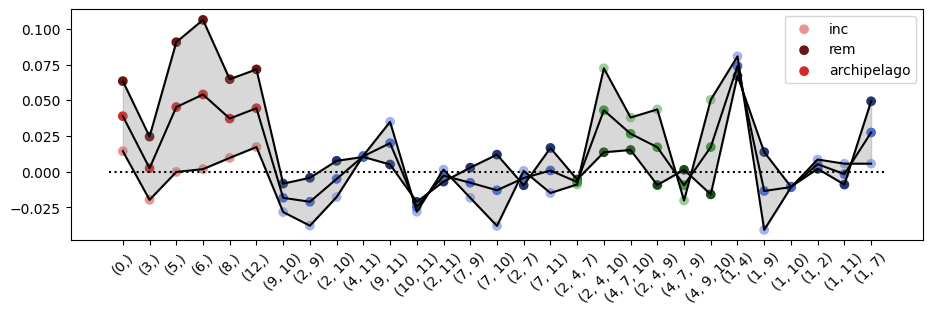

new_selections [(1, 4)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,), (1, 4)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (1, 4), (9, 10), (2, 9), (9, 11), (7, 9), (1, 9), (2, 10), (10, 11), (7, 10), (1, 10), (2, 11), (2, 7), (1, 2), (7, 11), (1, 11), (1, 7), (2, 4, 7), (2, 4, 10), (2, 4, 9), (1, 2, 4), (4, 7, 10), (4, 7, 9), (1, 4, 7), (4, 9, 10), (1, 4, 10), (1, 4, 9)]
candidates [(0,), (3,), (5,), (6,), (8,), (12,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10), (1, 9), (1, 10), (1, 2), (1, 11), (1, 7), (1, 2, 4), (1, 4, 7), (1, 4, 10), (1, 4, 9)]
1.759997844696045 seconds
nr 12
archipelago_tensor (32, 2, 4171)
semitruth torch.Size([4171, 1])


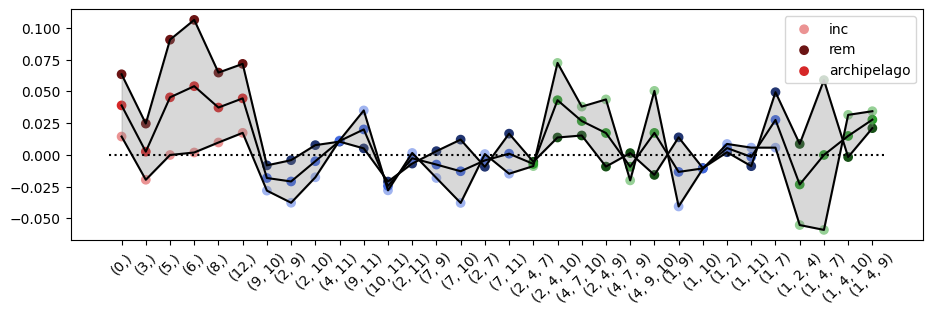

new_selections [(6,)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,), (1, 4), (6,)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (1, 4), (4, 6), (9, 10), (2, 9), (9, 11), (7, 9), (1, 9), (6, 9), (2, 10), (10, 11), (7, 10), (1, 10), (6, 10), (2, 11), (2, 7), (1, 2), (2, 6), (7, 11), (1, 11), (6, 11), (1, 7), (6, 7), (1, 6), (2, 4, 7), (2, 4, 10), (2, 4, 9), (1, 2, 4), (4, 7, 10), (4, 7, 9), (1, 4, 7), (4, 9, 10), (1, 4, 10), (1, 4, 9)]
candidates [(0,), (3,), (5,), (8,), (12,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10), (1, 9), (1, 10), (1, 2), (1, 11), (1, 7), (1, 2, 4), (1, 4, 7), (1, 4, 10), (1, 4, 9), (4, 6), (6, 9), (6, 10), (2, 6), (6, 11), (6, 7), (1, 6)]
1.980107069015503 seconds
nr 13
archipelago_tensor (38, 2, 4171)
semitruth torch.Size([4171, 1])


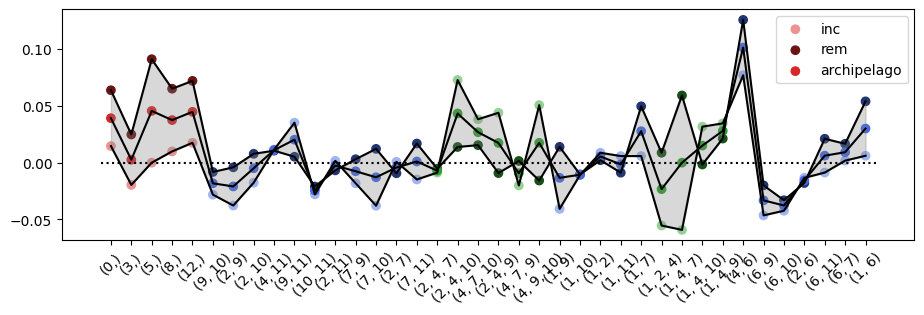

new_selections [(4, 6)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,), (1, 4), (6,), (4, 6)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (1, 4), (4, 6), (9, 10), (2, 9), (9, 11), (7, 9), (1, 9), (6, 9), (2, 10), (10, 11), (7, 10), (1, 10), (6, 10), (2, 11), (2, 7), (1, 2), (2, 6), (7, 11), (1, 11), (6, 11), (1, 7), (6, 7), (1, 6), (2, 4, 7), (2, 4, 10), (2, 4, 9), (1, 2, 4), (2, 4, 6), (4, 7, 10), (4, 7, 9), (1, 4, 7), (4, 6, 7), (4, 9, 10), (1, 4, 10), (4, 6, 10), (1, 4, 9), (4, 6, 9), (1, 4, 6)]
candidates [(0,), (3,), (5,), (8,), (12,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10), (1, 9), (1, 10), (1, 2), (1, 11), (1, 7), (1, 2, 4), (1, 4, 7), (1, 4, 10), (1, 4, 9), (6, 9), (6, 10), (2, 6), (6, 11), (6, 7), (1, 6), (2, 4, 6), (4, 6, 7), (4, 6, 10), (4, 6, 9), (1, 4, 6)]
2.234616994857788 seconds
nr 14
archipelago_

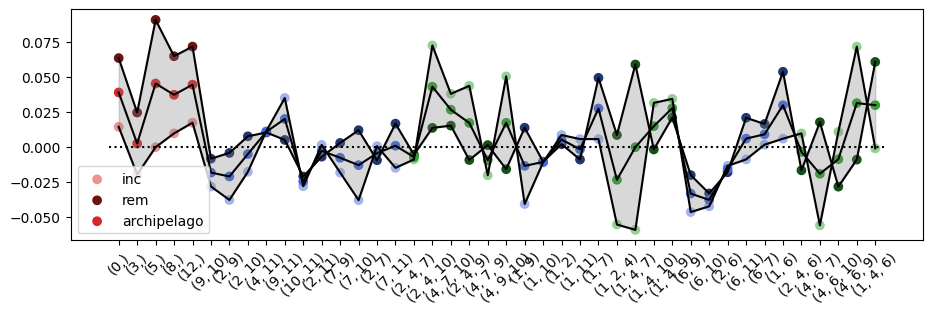

new_selections [(5,)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,), (1, 4), (6,), (4, 6), (5,)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (1, 4), (4, 6), (4, 5), (9, 10), (2, 9), (9, 11), (7, 9), (1, 9), (6, 9), (5, 9), (2, 10), (10, 11), (7, 10), (1, 10), (6, 10), (5, 10), (2, 11), (2, 7), (1, 2), (2, 6), (2, 5), (7, 11), (1, 11), (6, 11), (5, 11), (1, 7), (6, 7), (5, 7), (1, 6), (1, 5), (5, 6), (2, 4, 7), (2, 4, 10), (2, 4, 9), (1, 2, 4), (2, 4, 6), (4, 7, 10), (4, 7, 9), (1, 4, 7), (4, 6, 7), (4, 9, 10), (1, 4, 10), (4, 6, 10), (1, 4, 9), (4, 6, 9), (1, 4, 6)]
candidates [(0,), (3,), (8,), (12,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10), (1, 9), (1, 10), (1, 2), (1, 11), (1, 7), (1, 2, 4), (1, 4, 7), (1, 4, 10), (1, 4, 9), (6, 9), (6, 10), (2, 6), (6, 11), (6, 7), (1, 6), (2, 4, 6), (4, 6, 7), (4, 6, 10), (4

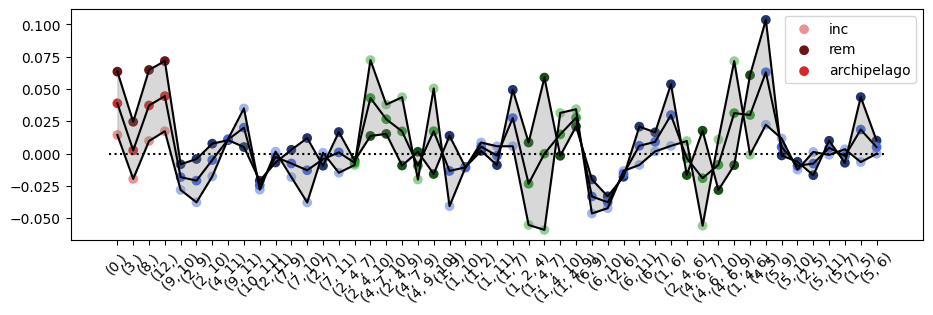

new_selections [(4, 5)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,), (1, 4), (6,), (4, 6), (5,), (4, 5)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (1, 4), (4, 6), (4, 5), (9, 10), (2, 9), (9, 11), (7, 9), (1, 9), (6, 9), (5, 9), (2, 10), (10, 11), (7, 10), (1, 10), (6, 10), (5, 10), (2, 11), (2, 7), (1, 2), (2, 6), (2, 5), (7, 11), (1, 11), (6, 11), (5, 11), (1, 7), (6, 7), (5, 7), (1, 6), (1, 5), (5, 6), (2, 4, 7), (2, 4, 10), (2, 4, 9), (1, 2, 4), (2, 4, 6), (2, 4, 5), (4, 7, 10), (4, 7, 9), (1, 4, 7), (4, 6, 7), (4, 5, 7), (4, 9, 10), (1, 4, 10), (4, 6, 10), (4, 5, 10), (1, 4, 9), (4, 6, 9), (4, 5, 9), (1, 4, 6), (1, 4, 5), (4, 5, 6)]
candidates [(0,), (3,), (8,), (12,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10), (1, 9), (1, 10), (1, 2), (1, 11), (1, 7), (1, 2, 4), (1, 4, 7), (1, 4, 10), (1, 4, 9), (6, 9), (

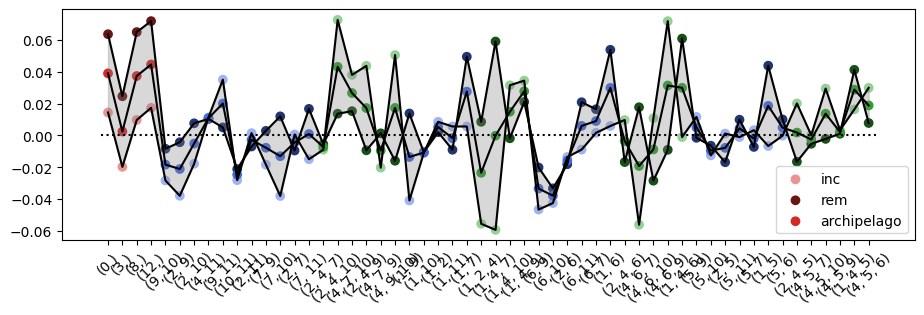

new_selections [(12,)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,), (1, 4), (6,), (4, 6), (5,), (4, 5), (12,)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (1, 4), (4, 6), (4, 5), (4, 12), (9, 10), (2, 9), (9, 11), (7, 9), (1, 9), (6, 9), (5, 9), (9, 12), (2, 10), (10, 11), (7, 10), (1, 10), (6, 10), (5, 10), (10, 12), (2, 11), (2, 7), (1, 2), (2, 6), (2, 5), (2, 12), (7, 11), (1, 11), (6, 11), (5, 11), (11, 12), (1, 7), (6, 7), (5, 7), (7, 12), (1, 6), (1, 5), (1, 12), (5, 6), (6, 12), (5, 12), (2, 4, 7), (2, 4, 10), (2, 4, 9), (1, 2, 4), (2, 4, 6), (2, 4, 5), (4, 7, 10), (4, 7, 9), (1, 4, 7), (4, 6, 7), (4, 5, 7), (4, 9, 10), (1, 4, 10), (4, 6, 10), (4, 5, 10), (1, 4, 9), (4, 6, 9), (4, 5, 9), (1, 4, 6), (1, 4, 5), (4, 5, 6)]
candidates [(0,), (3,), (8,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (2, 4, 10), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10), (1, 9), (1, 10

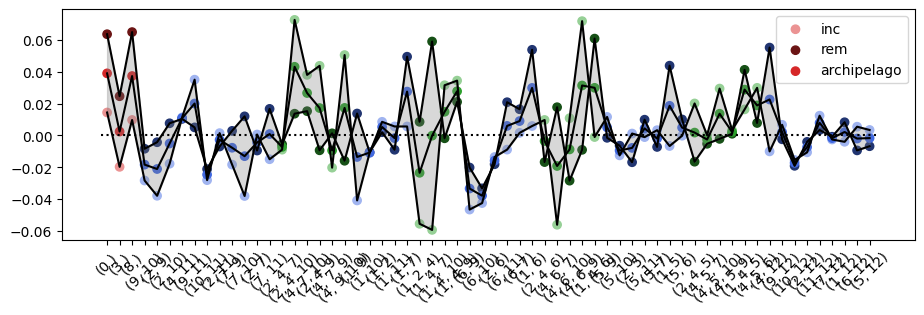

new_selections [(2, 4, 10)]
selections [(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,), (1, 4), (6,), (4, 6), (5,), (4, 5), (12,), (2, 4, 10)]
new_cands [(4, 9), (4, 10), (2, 4), (4, 11), (4, 7), (1, 4), (4, 6), (4, 5), (4, 12), (9, 10), (2, 9), (9, 11), (7, 9), (1, 9), (6, 9), (5, 9), (9, 12), (2, 10), (10, 11), (7, 10), (1, 10), (6, 10), (5, 10), (10, 12), (2, 11), (2, 7), (1, 2), (2, 6), (2, 5), (2, 12), (7, 11), (1, 11), (6, 11), (5, 11), (11, 12), (1, 7), (6, 7), (5, 7), (7, 12), (1, 6), (1, 5), (1, 12), (5, 6), (6, 12), (5, 12), (2, 4, 7), (2, 4, 10), (2, 4, 9), (1, 2, 4), (2, 4, 6), (2, 4, 5), (4, 7, 10), (4, 7, 9), (1, 4, 7), (4, 6, 7), (4, 5, 7), (4, 9, 10), (1, 4, 10), (4, 6, 10), (4, 5, 10), (1, 4, 9), (4, 6, 9), (4, 5, 9), (1, 4, 6), (1, 4, 5), (4, 5, 6)]
candidates [(0,), (3,), (8,), (9, 10), (2, 9), (2, 10), (4, 11), (9, 11), (10, 11), (2, 11), (7, 9), (7, 10), (2, 7), (7, 11), (2, 4, 7), (4, 7, 10), (2, 4, 9), (4, 7, 9), (4, 9, 10), (1, 9), (

In [6]:
results_path = "../results/"
exp_folder = results_path+'_'+ "demo" +'_simple_testing/'
os.makedirs(exp_folder, exist_ok=True)

mlp_args = TrainingArgs(batch_size=32, number_of_epochs=10, learning_rate=5e-3, device=device) 
mlp_args.model_config.net_name = "MLP"
mlp_args.model_config.sizes = [-1, 128, 256, 128, -1]
mlp_args.model_config.is_masked = True  
mlp_args.saving_settings.exp_folder = exp_folder
 
my_surrogate = surrogate(mlp_args=mlp_args, dataset_obj=dataset_obj, max_number_of_rounds=18, order=3)
interactions = my_surrogate.get_interactions(device=device)
transform_matrix = my_surrogate.get_transform_matrix()

print(f"\nFound interactions: {interactions}")

In [7]:
print(interactions)

[(4,), (9,), (10,), (2,), (2, 4), (11,), (7,), (4, 7), (4, 10), (4, 9), (1,), (1, 4), (6,), (4, 6), (5,), (4, 5), (12,), (2, 4, 10)]


## Step3: train the InstaSHAP

In [8]:
# prepare DataLoader for InstaSHAP training
X_train = torch.from_numpy(dataset_obj.trnX).float().to(device)
Y_train = torch.from_numpy(dataset_obj.trnY).float().to(device)
y_mean = Y_train.mean() # normalization
Y_centered = Y_train - y_mean
train_dataset = TensorDataset(X_train, Y_centered)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# train the model
instashap_model = InstaSHAP(interactions, transform_matrix, device=device)
instashap_model.train_instaSHAP(train_loader, num_epochs=30, lr=1e-2, device=device)

Epoch 1/30: 100%|██████████| 305/305 [00:00<00:00, 672.64it/s]


Epoch 1, Loss: 1.6536


Epoch 2/30: 100%|██████████| 305/305 [00:00<00:00, 688.50it/s]


Epoch 2, Loss: 1.4048


Epoch 3/30: 100%|██████████| 305/305 [00:00<00:00, 696.32it/s]


...

Epoch 28, Loss: 1.2399


Epoch 29/30: 100%|██████████| 305/305 [00:00<00:00, 653.80it/s]


Epoch 29, Loss: 1.2421


Epoch 30/30: 100%|██████████| 305/305 [00:00<00:00, 636.50it/s]

Epoch 30, Loss: 1.2390


## Step4: evaluate the SHAP value

In [9]:
instashap_model.eval()
with torch.no_grad():

    sample_x = X_train[0:1]
    sample_y = Y_centered[0:1]
    
    # 预测 (全特征 Mask)
    full_mask = torch.ones_like(sample_x)
    pred = instashap_model(sample_x, full_mask)
    
    print(f"\nTest Sample 0:")
    print(f"True Centered Y: {sample_y.item():.4f}")
    print(f"Pred Centered Y: {pred.item():.4f}")

    shap = instashap_model.get_shapley_values(sample_x)
    print(f"SHAP values: {shap.cpu().numpy()}")


Test Sample 0:
True Centered Y: 1.3528
Pred Centered Y: 1.0113
SHAP values: [[ 0.41066912  0.16751477  0.21268016  0.23102833 -0.19339728  0.04677311
  -0.02735945  0.29026708 -0.08813119  0.08051789  0.13801642 -0.0688981
   0.13260962 -0.01651023  0.06798628  0.00846618 -0.380979  ]]


In [10]:
from sklearn.metrics import r2_score, mean_squared_error

X_train = torch.from_numpy(dataset_obj.trnX).float().to(device)
Y_train = torch.from_numpy(dataset_obj.trnY).float().to(device)

instashap_model.eval() 
with torch.no_grad():

    full_mask = torch.ones_like(X_train)
    
    preds_centered = instashap_model(X_train, full_mask)
    
    preds_original = preds_centered + y_mean

y_true = Y_train.cpu().numpy()
y_pred = preds_original.cpu().numpy()

r2 = r2_score(y_true, y_pred)

r2_error = 1 - r2

print(f"Test R2 Score: {r2:.4f}")
print(f"Test R2 Error (Unexplained Variance): {r2_error:.4f}")
print(f"Test MSE: {mean_squared_error(y_true, y_pred):.4f}")

Test R2 Score: 0.8369
Test R2 Error (Unexplained Variance): 0.1631
Test MSE: 0.3278


In [11]:
from sklearn.metrics import r2_score, mean_squared_error

X_test = torch.from_numpy(dataset_obj.tstX).float().to(device)
Y_test = torch.from_numpy(dataset_obj.tstY).float().to(device)

instashap_model.eval() 
with torch.no_grad():

    full_mask = torch.ones_like(X_test)
    
    preds_centered = instashap_model(X_test, full_mask)
    
    preds_original = preds_centered + y_mean

y_true = Y_test.cpu().numpy()
y_pred = preds_original.cpu().numpy()

r2 = r2_score(y_true, y_pred)

r2_error = 1 - r2

print(f"Test R2 Score: {r2:.4f}")
print(f"Test R2 Error (Unexplained Variance): {r2_error:.4f}")
print(f"Test MSE: {mean_squared_error(y_true, y_pred):.4f}")

Test R2 Score: 0.8480
Test R2 Error (Unexplained Variance): 0.1520
Test MSE: 0.2996
